In [1]:
import kaggle
from pathlib import Path

DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    "teejmahal20/airline-passenger-satisfaction",
    path=DATA_DIR,
    unzip=True,
)

print("Pobrane pliki:")
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name}")

Dataset URL: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
Pobrane pliki:
  test.csv
  train.csv


In [2]:
import os
import sys
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning:pkg_resources"

sys.path.append("..")

from sklearn.feature_selection import f_classif, mutual_info_classif

from src.preprocessing import (
    load_data,
    analyze_missing_values,
    clean_data,
    build_preprocessor,
    plot_correlation_matrix,
    plot_target_correlation,
    engineer_features,
    split_X_y,
)
from src.evaluation import evaluate, cross_validate_model, plot_pr_curve
from src.models.xgboost_model import tune_hyperparameters
from src.models.logistic_regression import tune_hyperparameters as tune_hyperparameters_lr
from src.models.random_forest import tune_hyperparameters as tune_hyperparameters_rf
from src.scripts.run_selectkbest_experiment import (
    run_selectkbest_experiment,
    get_feature_scores,
    plot_k_vs_metrics,
    plot_feature_scores,
)
from src.scripts.run_rfe_experiment import (
    run_rfe_experiment,
    get_feature_rankings,
    plot_n_features_vs_metrics,
    plot_feature_rankings,
)

In [3]:
train, test = load_data()

print("=== Train ===")
print(train.shape)
train.head()

=== Train ===
(103904, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
print("=== Braki w train ===")
analyze_missing_values(train)

print("\n=== Braki w test ===")
analyze_missing_values(test)

=== Braki w train ===
                          count  percent
Arrival Delay in Minutes    310      0.3

=== Braki w test ===
                          count  percent
Arrival Delay in Minutes     83     0.32


In [5]:
train_clean = clean_data(train)
test_clean = clean_data(test)

print("Train po czyszczeniu:", train_clean.shape)
print("Test po czyszczeniu: ", test_clean.shape)

Train po czyszczeniu: (103904, 23)
Test po czyszczeniu:  (25976, 23)


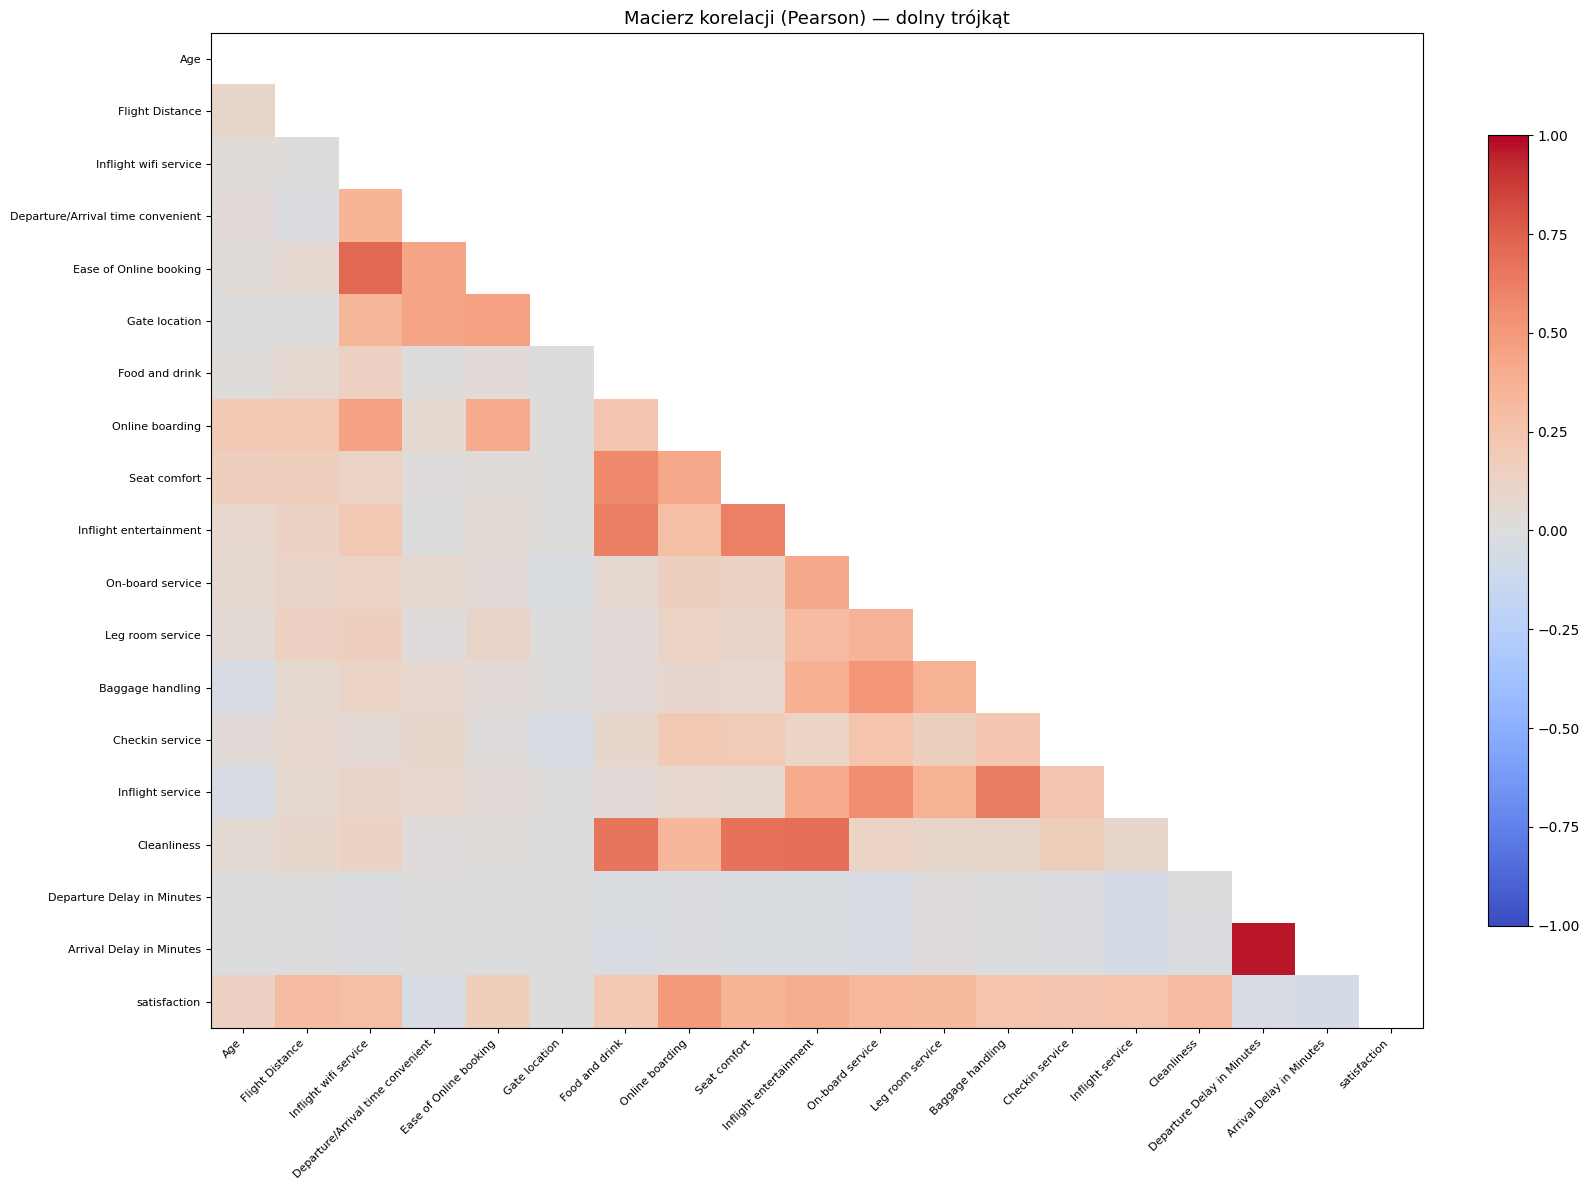

In [6]:
plot_correlation_matrix(train_clean)

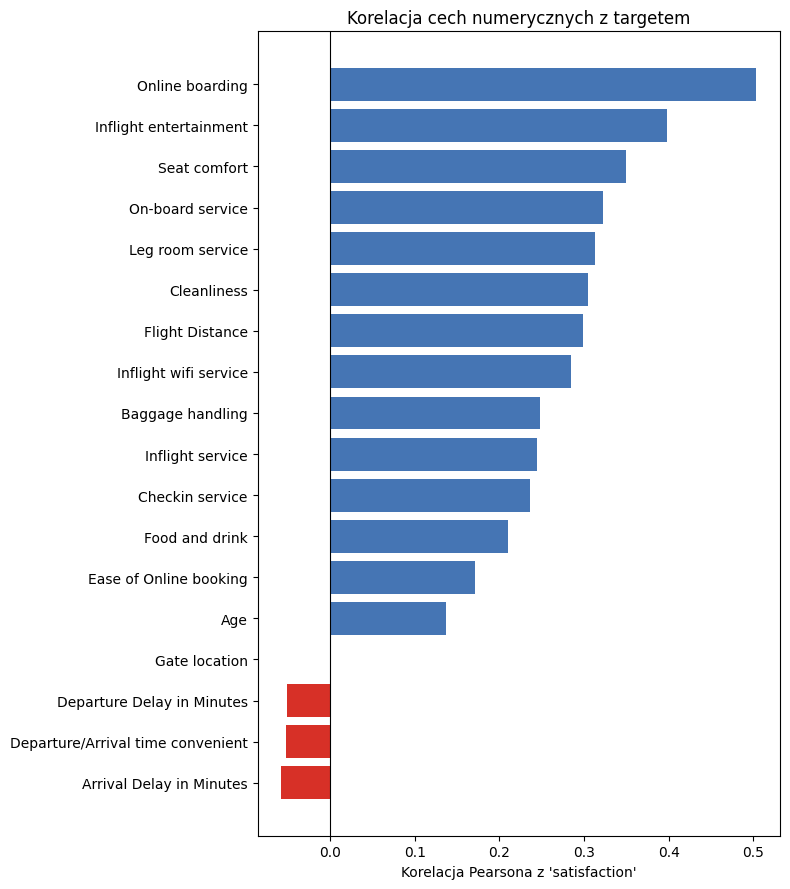

In [7]:
plot_target_correlation(train_clean)

In [8]:
train_feat = engineer_features(train_clean)
test_feat = engineer_features(test_clean)

print("Nowe kolumny:", [c for c in train_feat.columns if c not in train_clean.columns])
train_feat[["Departure Delay in Minutes", "Arrival Delay in Minutes", "total_delay", "avg_service_score"]].describe()

Nowe kolumny: ['total_delay', 'avg_service_score']


,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay,avg_service_score
count,103904.000000,103594.000000,103594.000000,103904.000000
mean,14.815618,15.178678,29.926617,3.261020
std,38.230901,38.698682,76.149672,0.687624
min,0.000000,0.000000,0.000000,0.846154
25%,0.000000,0.000000,0.000000,2.769231
50%,0.000000,0.000000,2.000000,3.307692
75%,12.000000,13.000000,24.000000,3.769231
max,1592.000000,1584.000000,3176.000000,5.000000


In [9]:
X_train, y_train = split_X_y(train_feat)
X_test, y_test = split_X_y(test_feat)

preprocessor = build_preprocessor(X_train)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Rozkład klas y_train:\n", y_train.value_counts())

X_train shape: (103904, 24)
X_test shape:  (25976, 24)
Rozkład klas y_train:
 satisfaction
0    58879
1    45025
Name: count, dtype: int64


In [10]:
# Fast mode: ograniczamy zbiór treningowy do 10 000 próbek
from sklearn.model_selection import train_test_split as _tts
X_train, _, y_train, _ = _tts(
    X_train, y_train, train_size=10_000, stratify=y_train, random_state=42
)
preprocessor = build_preprocessor(X_train)
print(f"Fast mode — X_train zredukowany do {X_train.shape}")

Fast mode — X_train zredukowany do (10000, 24)


## Model Regresji Logistycznej

In [11]:
search = tune_hyperparameters_lr(preprocessor, X_train, y_train, cv=3)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Najlepsze parametry:
  model__C: 0.1
  model__l1_ratio: 1.0

Najlepsze F1 (CV): 0.8566


In [12]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train, cv=3)

print("Walidacja krzyżowa najlepszego modelu (3-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

Walidacja krzyżowa najlepszego modelu (3-fold):
 accuracy       f1  roc_auc
 0.880324 0.858360 0.928723
 0.880288 0.858360 0.929259
 0.874887 0.852598 0.924207

Średnie:
accuracy    0.8785
f1          0.8564
roc_auc     0.9274

Odchylenia standardowe:
accuracy    0.0031
f1          0.0033
roc_auc     0.0028


In [13]:
best_model = search.best_estimator_
metrics = evaluate(best_model, X_test, y_test)

accuracy    0.8717
f1          0.8506
roc_auc     0.9255

              precision    recall  f1-score   support

dissatisfied       0.87      0.90      0.89     14573
   satisfied       0.87      0.83      0.85     11403

    accuracy                           0.87     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.87      0.87      0.87     25976



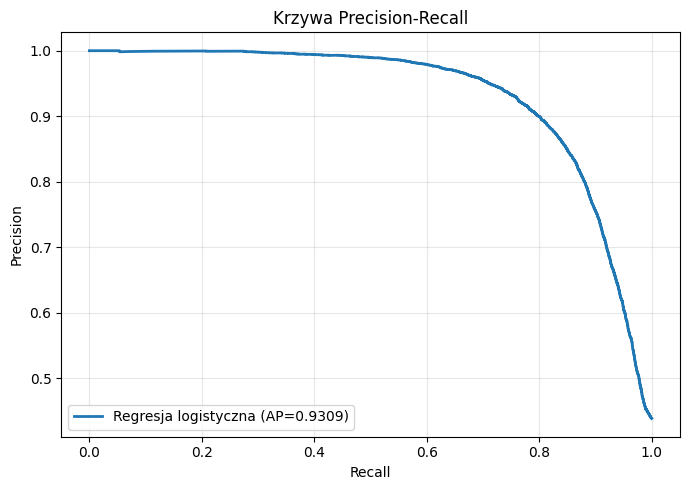

In [14]:
plot_pr_curve(best_model, X_test, y_test, label="Regresja logistyczna")

## Model Las Losowy

In [15]:
search = tune_hyperparameters_rf(preprocessor, X_train, y_train, cv=3)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Najlepsze parametry:
  model__max_depth: None
  model__min_samples_split: 2
  model__n_estimators: 500

Najlepsze F1 (CV): 0.9362


In [16]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train, cv=3)

print("Walidacja krzyżowa najlepszego modelu (3-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

Walidacja krzyżowa najlepszego modelu (3-fold):
 accuracy       f1  roc_auc
 0.939412 0.928923 0.985906
 0.944194 0.935192 0.988559
 0.953795 0.945506 0.989143

Średnie:
accuracy    0.9458
f1          0.9365
roc_auc     0.9879

Odchylenia standardowe:
accuracy    0.0073
f1          0.0084
roc_auc     0.0017


In [17]:
best_model = search.best_estimator_
metrics = evaluate(best_model, X_test, y_test)

accuracy    0.9495
f1          0.9420
roc_auc     0.9895

              precision    recall  f1-score   support

dissatisfied       0.95      0.96      0.96     14573
   satisfied       0.95      0.93      0.94     11403

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



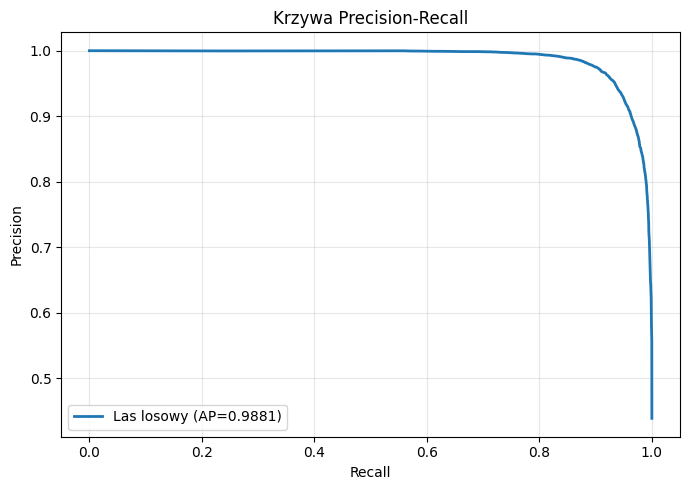

In [18]:
plot_pr_curve(best_model, X_test, y_test, label="Las losowy")

## Model XGBoost

In [19]:
search = tune_hyperparameters(preprocessor, X_train, y_train, cv=3)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Najlepsze parametry:
  model__learning_rate: 0.1
  model__max_depth: 7
  model__n_estimators: 500

Najlepsze F1 (CV): 0.9422


In [20]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train, cv=3)

print("Walidacja krzyżowa najlepszego modelu (3-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

Walidacja krzyżowa najlepszego modelu (3-fold):
 accuracy       f1  roc_auc
 0.949610 0.940928 0.988920
 0.954095 0.947004 0.991675
 0.953795 0.945467 0.990137

Średnie:
accuracy    0.9525
f1          0.9445
roc_auc     0.9902

Odchylenia standardowe:
accuracy    0.0025
f1          0.0032
roc_auc     0.0014


In [21]:
best_model = search.best_estimator_
metrics = evaluate(best_model, X_test, y_test)

accuracy    0.9558
f1          0.9491
roc_auc     0.9923

              precision    recall  f1-score   support

dissatisfied       0.95      0.97      0.96     14573
   satisfied       0.96      0.94      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.95      0.96     25976
weighted avg       0.96      0.96      0.96     25976



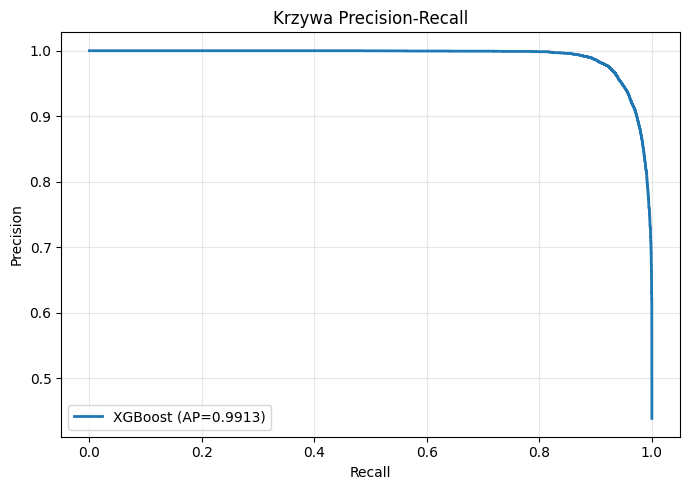

In [22]:
plot_pr_curve(best_model, X_test, y_test, label="XGBoost")

## Eksperyment: TabPFN vs pozostałe modele dla różnych rozmiarów próbek treningowych

Porównanie jakości obu modeli na tym samym zbiorze testowym, przy różnej liczbie próbek użytych do trenowania. Celem jest porównanie wyników modeli dla małych próbek danych.

In [23]:
import subprocess, sys, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

In [24]:
script = "src/scripts/run_tabpfn_experiment.py"
env = {**os.environ, "TABPFN_SAMPLE_SIZES": "100"}
with subprocess.Popen(
    [sys.executable, "-u", str(script)],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    cwd="..",
    env=env,
) as proc:
    for line in iter(proc.stdout.readline, ""):
        print(line, end="", flush=True)
    proc.wait()
    if proc.returncode != 0:
        print(f"\nBłąd: skrypt zakończył się kodem {proc.returncode}")

Ładowanie i przygotowanie danych...
X_train: (103904, 24) → 29 cech po OHE
X_test:  (25976, 24)

--- sample_size = 100 ---
  TabPFN:  f1=0.8946  roc_auc=0.9702
  XGBoost: f1=0.8330  roc_auc=0.9202
  RF:      f1=0.8548  roc_auc=0.9467

Wyniki zapisane do data/tabpfn_experiment_results.csv


In [25]:
results_df = pd.read_csv("../data/tabpfn_experiment_results.csv").set_index(["model", "sample_size"])
print(results_df.round(4).to_string())

                     accuracy      f1  roc_auc
model   sample_size                           
TabPFN  100            0.9075  0.8946   0.9702
XGBoost 100            0.8494  0.8330   0.9202
RF      100            0.8757  0.8548   0.9467


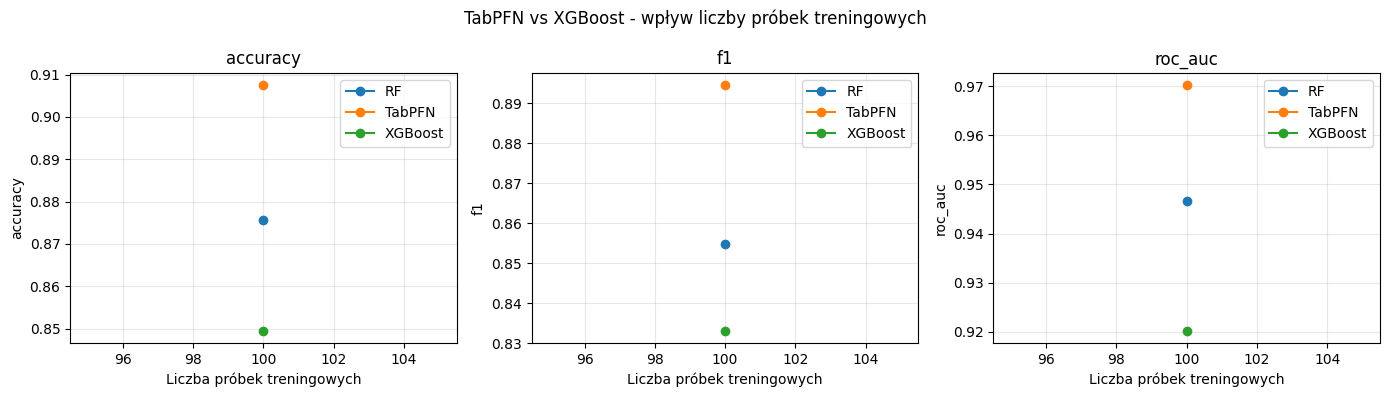

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ["accuracy", "f1", "roc_auc"]):
    for model_name, group in results_df.reset_index().groupby("model"):
        ax.plot(group["sample_size"], group[metric], marker="o", label=model_name)
    ax.set_title(metric)
    ax.set_xlabel("Liczba próbek treningowych")
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("TabPFN vs XGBoost - wpływ liczby próbek treningowych")
plt.tight_layout()
plt.show()

## Eksperyment: Wpływ liczby wybranych cech na jakość modelu przy użyciu algorytmu SelectKBest

Porównanie jakości modelu Regresji Logistycznej w zależności od liczby wybranych cech (`k`) oraz funkcji wyboru cech (`score_func`). Celem jest zbadanie, jak różne wartości `k` oraz różne funkcje oceny wpływają na jakość modelu.

In [27]:
results = run_selectkbest_experiment(
    preprocessor, X_train, y_train, X_test, y_test,
    k_values=[5, 10, 15, 20, 25, "all"],
    score_funcs=[f_classif, mutual_info_classif]
)


── f_classif ──
  k=   5  accuracy=0.8441  f1=0.8199  roc_auc=0.9048
  k=  10  accuracy=0.8506  f1=0.8258  roc_auc=0.9084
  k=  15  accuracy=0.8502  f1=0.8253  roc_auc=0.9091
  k=  20  accuracy=0.8667  f1=0.8443  roc_auc=0.9205
  k=  25  accuracy=0.8678  f1=0.8455  roc_auc=0.9210
  k= all  accuracy=0.8679  f1=0.8457  roc_auc=0.9224

── mutual_info_classif ──
  k=   5  accuracy=0.8205  f1=0.7897  roc_auc=0.8846
  k=  10  accuracy=0.8462  f1=0.8211  roc_auc=0.9070
  k=  15  accuracy=0.8535  f1=0.8291  roc_auc=0.9106
  k=  20  accuracy=0.8667  f1=0.8443  roc_auc=0.9205
  k=  25  accuracy=0.8681  f1=0.8459  roc_auc=0.9211
  k= all  accuracy=0.8679  f1=0.8457  roc_auc=0.9224


In [28]:
print(results.to_string(index=False))

         score_func   k  accuracy       f1  roc_auc
          f_classif   5  0.844125 0.819892 0.904816
          f_classif  10  0.850631 0.825822 0.908379
          f_classif  15  0.850246 0.825326 0.909051
          f_classif  20  0.866723 0.844293 0.920500
          f_classif  25  0.867840 0.845534 0.921042
          f_classif all  0.867878 0.845683 0.922359
mutual_info_classif   5  0.820488 0.789737 0.884566
mutual_info_classif  10  0.846243 0.821105 0.907025
mutual_info_classif  15  0.853519 0.829119 0.910635
mutual_info_classif  20  0.866723 0.844293 0.920499
mutual_info_classif  25  0.868148 0.845922 0.921113
mutual_info_classif all  0.867878 0.845683 0.922359


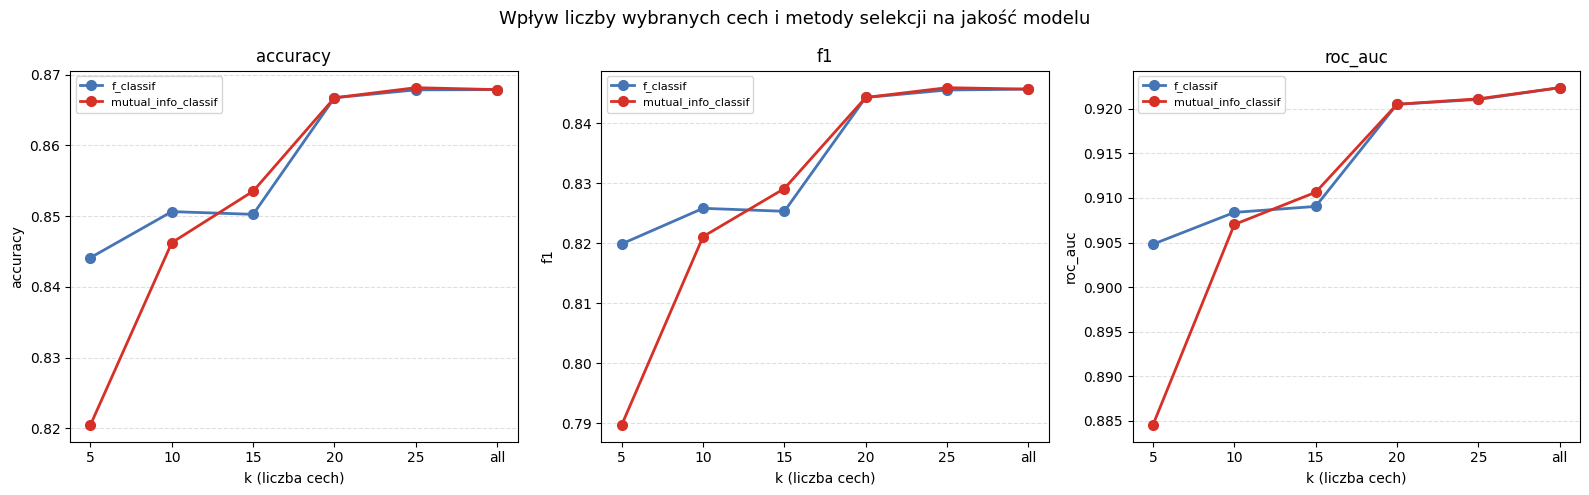

In [29]:
plot_k_vs_metrics(results)

In [30]:
scores_f = get_feature_scores(preprocessor, X_train, y_train, f_classif)
scores_f

,feature,score_func,score,p_value,rank
0,num__avg_service_score,f_classif,3754.652381,0.000000e+00,1
1,num__Online boarding,f_classif,3539.888606,0.000000e+00,2
2,cat__Class_Business,f_classif,3487.976020,0.000000e+00,3
3,cat__Class_Eco,f_classif,2611.850076,0.000000e+00,4
4,cat__Type of Travel_Business travel,f_classif,2509.732830,0.000000e+00,5
5,cat__Type of Travel_Personal Travel,f_classif,2509.732830,0.000000e+00,6
6,num__Inflight entertainment,f_classif,1913.446340,0.000000e+00,7
7,num__Seat comfort,f_classif,1414.456576,1.209202e-289,8
8,num__On-board service,f_classif,1172.558080,4.271125e-243,9
9,num__Leg room service,f_classif,1141.225709,5.418998e-237,10


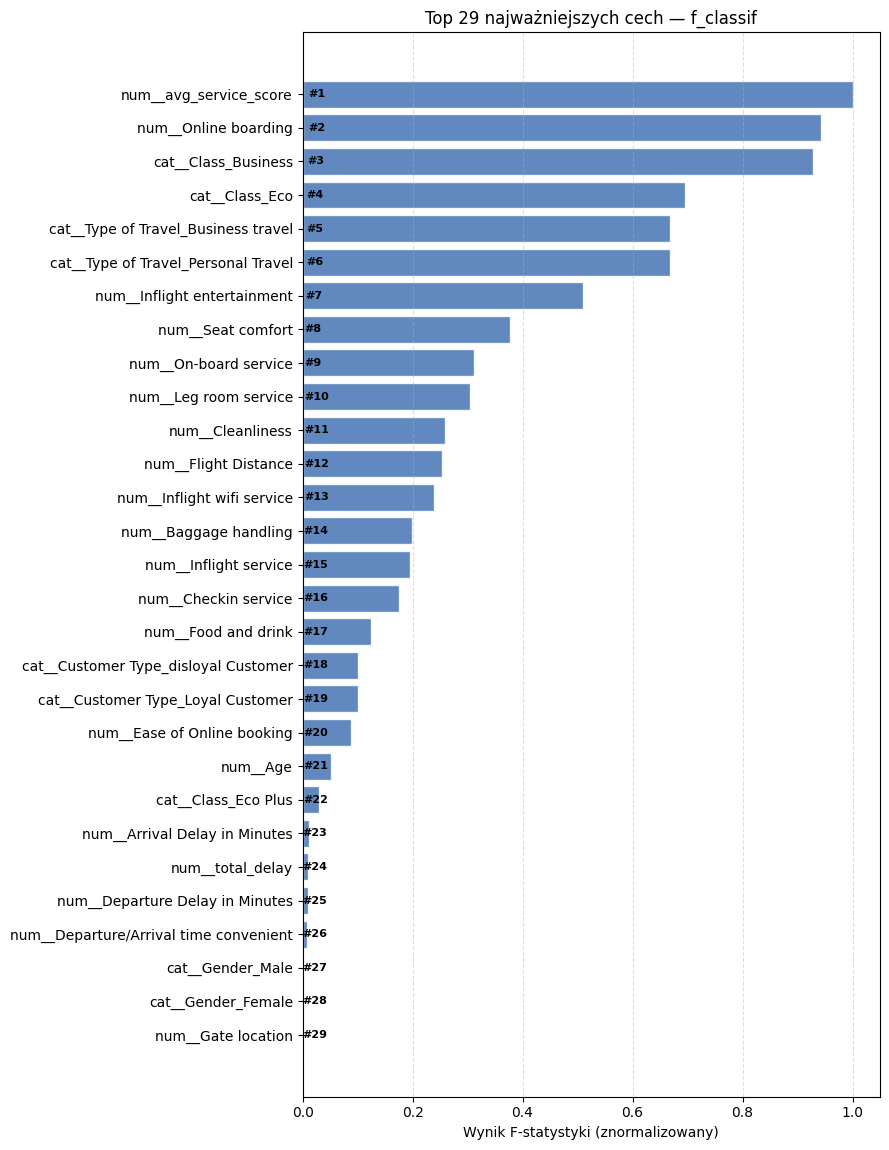

In [31]:
plot_feature_scores(scores_f,  top_n=29)

In [32]:
scores_mi = get_feature_scores(preprocessor, X_train, y_train, mutual_info_classif)
scores_mi

,feature,score_func,score,p_value,rank
0,num__Online boarding,mutual_info_classif,0.214122,NaN,1
1,num__avg_service_score,mutual_info_classif,0.166251,NaN,2
2,num__Inflight wifi service,mutual_info_classif,0.154444,NaN,3
3,cat__Class_Business,mutual_info_classif,0.134303,NaN,4
4,cat__Class_Eco,mutual_info_classif,0.110140,NaN,5
5,cat__Type of Travel_Business travel,mutual_info_classif,0.106092,NaN,6
6,cat__Type of Travel_Personal Travel,mutual_info_classif,0.105437,NaN,7
7,num__Inflight entertainment,mutual_info_classif,0.094456,NaN,8
8,num__Seat comfort,mutual_info_classif,0.080804,NaN,9
9,num__Leg room service,mutual_info_classif,0.062794,NaN,10


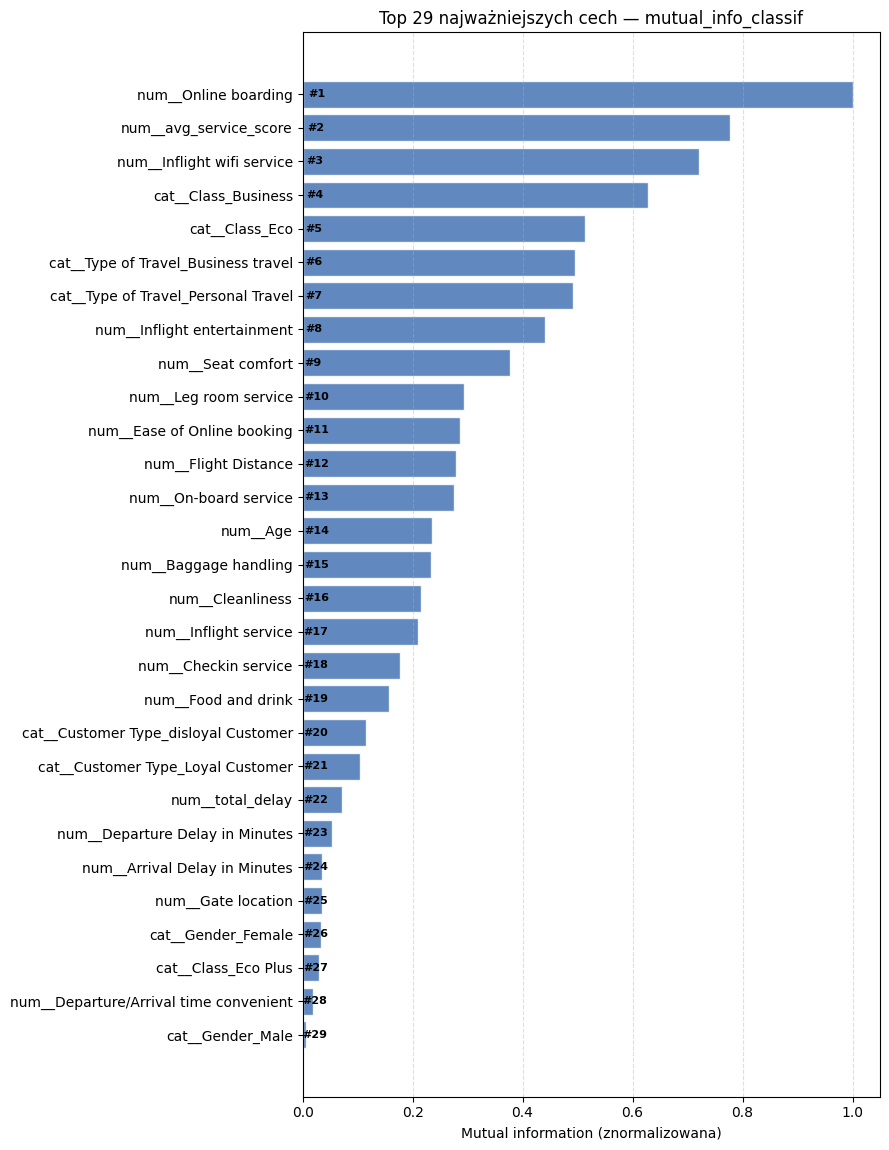

In [33]:
plot_feature_scores(scores_mi, top_n=29)

## Eksperyment: Wpływ liczby wybranych cech na jakość modelu przy użyciu algorytmu RFE

Porównanie jakości modelu Regresji Logistycznej w zależności od liczby wybranych cech (`n_features_to_select`) oraz estymatora użytego do rankowania cech (`estimator`). Badane estymatory: Regresja Logistyczna (LR) i Las Losowy (RF).

In [34]:
# Fast mode: zmniejszamy liczbę drzew RF używanych w RFE
from sklearn.ensemble import RandomForestClassifier as _RFC
from sklearn.linear_model import LogisticRegression as _LR

_fast_rfe_estimators = {
    "LR": _LR(C=0.01, l1_ratio=1.0, solver="saga", max_iter=5000, random_state=42),
    "RF": _RFC(n_estimators=20, random_state=42, n_jobs=1),
}

In [35]:
results_rfe = run_rfe_experiment(
    preprocessor, X_train, y_train, X_test, y_test,
    estimators=_fast_rfe_estimators,
)

estimator=LR n_features=5 accuracy=0.8459 f1=0.8203 roc_auc=0.9048
estimator=LR n_features=10 accuracy=0.8625 f1=0.8393 roc_auc=0.9196
estimator=LR n_features=15 accuracy=0.8674 f1=0.8451 roc_auc=0.9222
estimator=LR n_features=20 accuracy=0.8679 f1=0.8457 roc_auc=0.9224
estimator=LR n_features=25 accuracy=0.8679 f1=0.8457 roc_auc=0.9224
estimator=LR n_features=all accuracy=0.8679 f1=0.8457 roc_auc=0.9224
estimator=RF n_features=5 accuracy=0.8215 f1=0.7910 roc_auc=0.8850
estimator=RF n_features=10 accuracy=0.8516 f1=0.8270 roc_auc=0.9095
estimator=RF n_features=15 accuracy=0.8643 f1=0.8416 roc_auc=0.9180
estimator=RF n_features=20 accuracy=0.8665 f1=0.8441 roc_auc=0.9206
estimator=RF n_features=25 accuracy=0.8679 f1=0.8457 roc_auc=0.9224
estimator=RF n_features=all accuracy=0.8679 f1=0.8457 roc_auc=0.9224


In [36]:
print(results_rfe.to_string(index=False))

estimator n_features  accuracy       f1  roc_auc
       LR          5  0.845858 0.820320 0.904845
       LR         10  0.862527 0.839340 0.919568
       LR         15  0.867378 0.845120 0.922163
       LR         20  0.867917 0.845721 0.922359
       LR         25  0.867878 0.845683 0.922359
       LR        all  0.867878 0.845683 0.922359
       RF          5  0.821489 0.791041 0.884975
       RF         10  0.851632 0.827020 0.909505
       RF         15  0.864259 0.841585 0.917951
       RF         20  0.866531 0.844145 0.920565
       RF         25  0.867878 0.845683 0.922359
       RF        all  0.867878 0.845683 0.922359


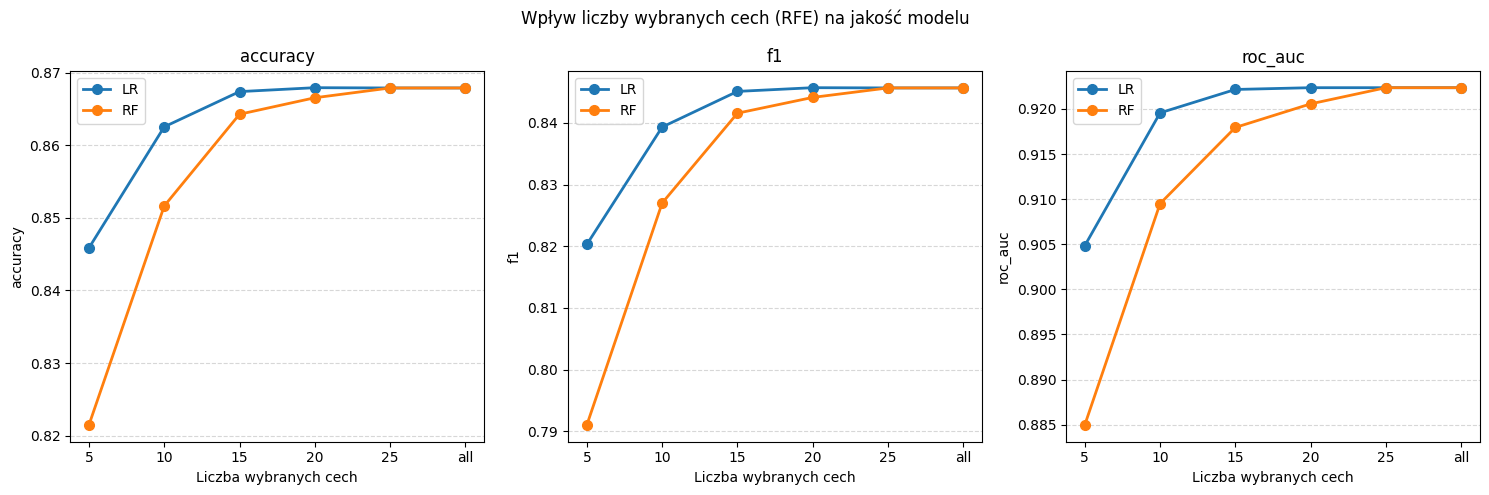

In [37]:
plot_n_features_vs_metrics(results_rfe)

In [38]:
rankings_lr = get_feature_rankings(
    preprocessor, X_train, y_train,
    estimator_name="LR",
    estimators=_fast_rfe_estimators,
)
rankings_lr

,feature,ranking
0,cat__Type of Travel_Personal Travel,1
1,num__avg_service_score,2
2,cat__Customer Type_disloyal Customer,3
3,cat__Class_Business,4
4,cat__Type of Travel_Business travel,5
5,num__Online boarding,6
6,num__Departure/Arrival time convenient,7
7,cat__Customer Type_Loyal Customer,8
8,num__On-board service,9
9,num__Leg room service,10


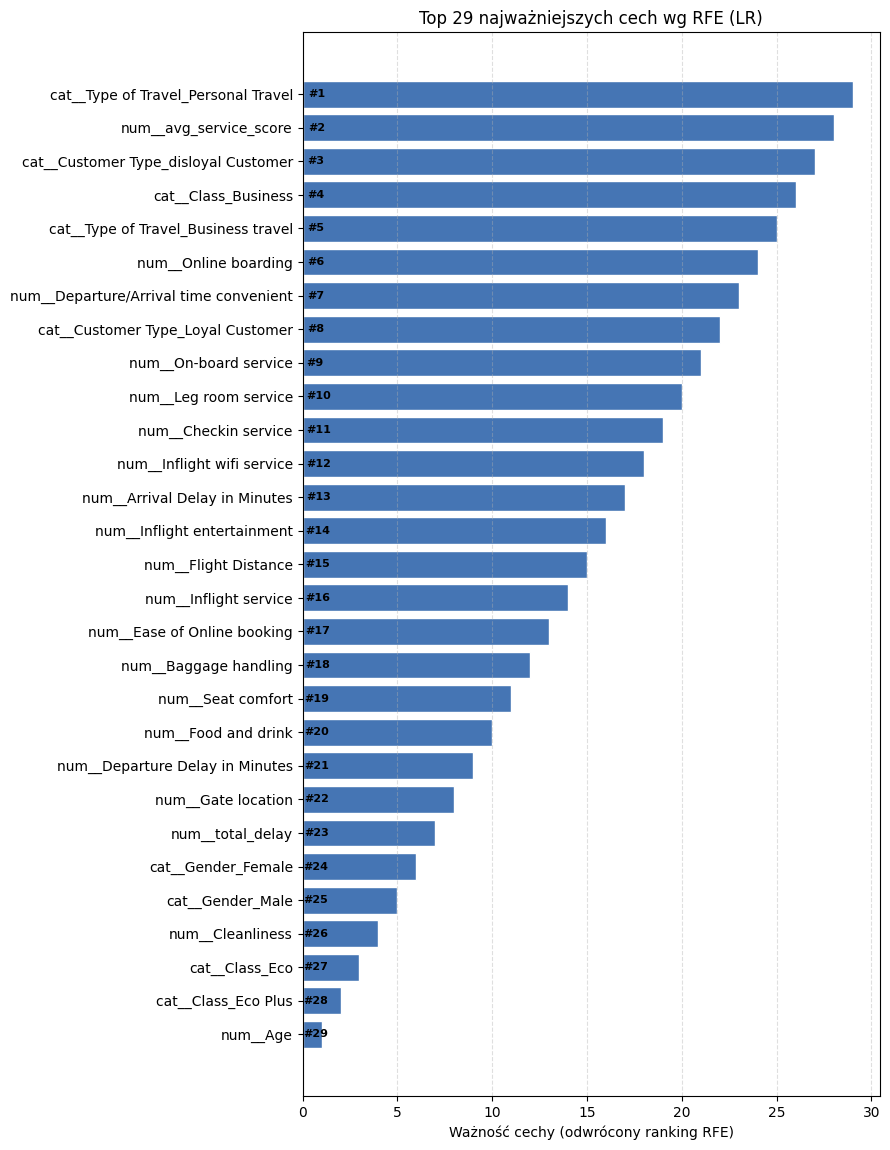

In [39]:
plot_feature_rankings(rankings_lr, estimator_name="LR", top_n=29)

In [40]:
rankings_rf = get_feature_rankings(
    preprocessor, X_train, y_train,
    estimator_name="RF",
    estimators=_fast_rfe_estimators,
)
rankings_rf

,feature,ranking
0,num__Flight Distance,1
1,num__Online boarding,2
2,num__Inflight wifi service,3
3,cat__Class_Business,4
4,num__avg_service_score,5
5,cat__Type of Travel_Personal Travel,6
6,num__Age,7
7,num__Inflight entertainment,8
8,num__Leg room service,9
9,num__Ease of Online booking,10


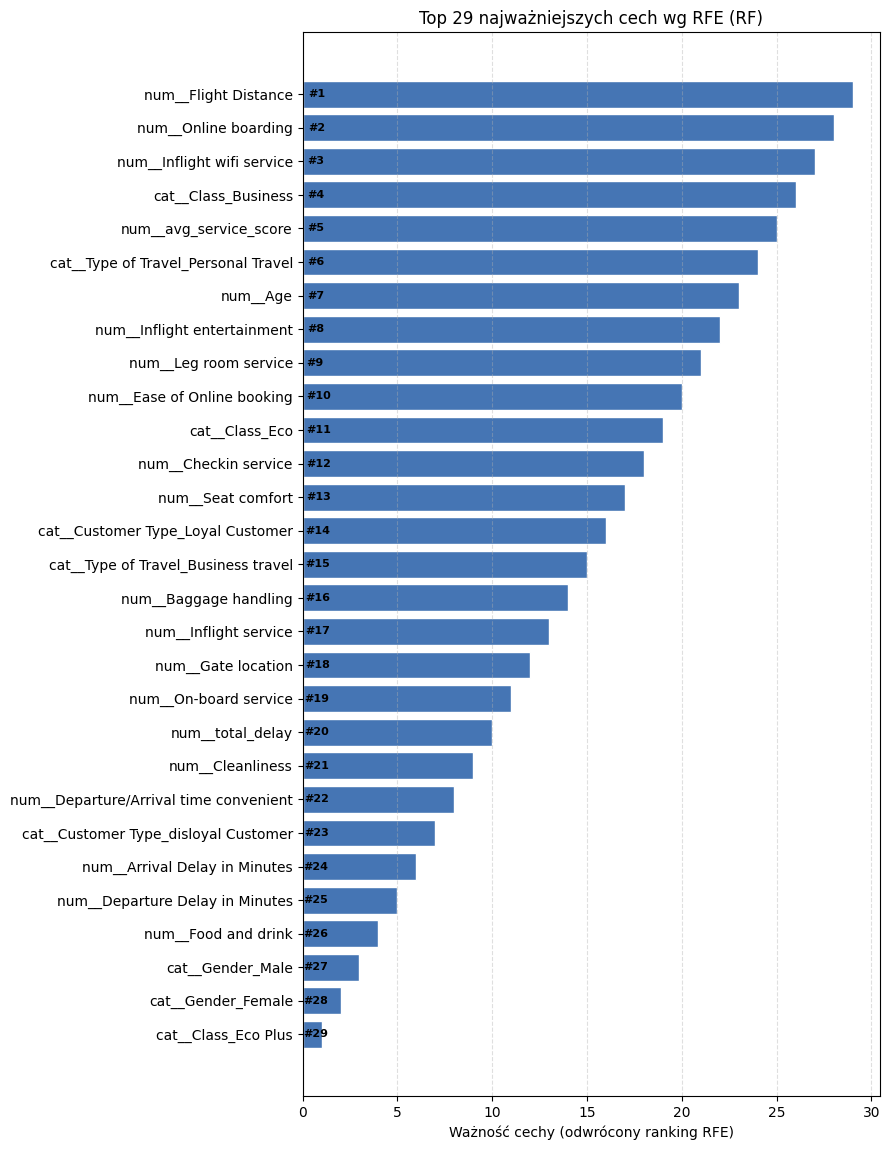

In [41]:
plot_feature_rankings(rankings_rf, estimator_name="RF", top_n=29)